## Problema - Organización y búsqueda de productos en una tienda

**Instrucción:** completa esta plantilla con tu diseño y desarrollo. Evita incluir soluciones generadas automáticamente.



In [1]:
# @title Ingrese datos
nombre_estudiante = "Thaliana Rocio Sierra Garcia" # @param {"type":"string"}
carnet = None # @param {"type":"integer"}


## 1) Descripción del problema **[1 pts]**

Un vivero registra cuántas plantas nuevas produce cada mes:

-En el mes 0 no produjo ninguna (el proceso apenas arrancaba).

-En el mes 1 produjo una.

-Desde el mes 2 en adelante, las plantas nuevas de un mes son la suma de las producidas en los dos meses anteriores: las que ya maduraron generan brotes, y a esas se suman las del mes pasado que van llegando a esa etapa.




## 2) Requerimientos **[2 pts]**

Lista requerimientos **funcionales** y **no funcionales**.

requerimientos funcionales:

-Rf-01 - calcular el valor del mes usando la recurrencia y los casos base

-Rf-02 - la memoización

-Rf-03 - recibir el mes a consultar

-Rf-04 - validar que sea entero


requerimientos no funcionales:


-Rnf-01 - rapido, el programa debe hacer pocas operaciones aunque el mes sea grande

-Rnf-02 - capacidad, debe poder calcular hasta el mes 1000 sin fallar

-Rnf-03 - robusto, si dan un dato inválido avisa del error


## 3) Historias de usuario **[2 pts]**
Escribe 3–5 historias de usuario con el formato visto en clase:
Incluye criterios de aceptación.

HU-01 - consultar un mes 

saber cuantas plantas nuevas habra en el mes n para planear el espacio y los materiales que se necesitan

criterios de aceptación:

-si pido el mes 0, me da 0, si pido el 1, me da 1, si pido el 10, me da 55

-el resultado siempre es un número entero de 0 en adelante

-funciona incluso con meses grandes como el 1000

HU-02 - avisar cuando el dato esta mal

que el programa me avise si escribo algo incorrecto para corregirlo sin que se cierre ni me de un numero falso

criterios de aceptación:

-si escribo -3, me avisa que el mes no puede ser negativo

-si escribo 4.5 o "diez", me avisa que debe ser un número entero

-que en ambos casos no muestra ningun resultado y el programa sigue funcionando

HU-03 - ver la producción mes por mes

una tabla con las plantas de cada mes y el total acumulado, para ver en que mes se llega a la meta

criterios de aceptación:

-si pido hasta el mes 6, la tabla muestra 0, 1, 1, 2, 3, 5, 8

-también muestra el acumulado: 0, 1, 2, 4, 7, 12, 20

-la tabla usa los valores ya calculados en vez de repetir el calculo




## 4) Diagramas de flujo **[5 pts]**
Incluye el diagrama que muestre el proceso general

Adjunta imagen y descríbelo claramente.


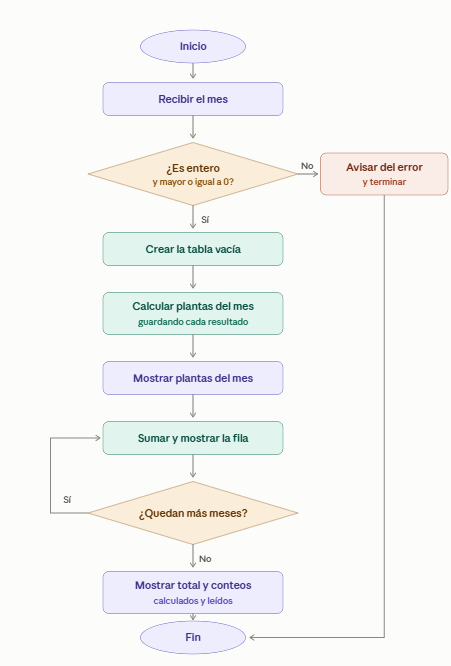

descripción del diagrama
1. inicio
2. se recibe el mes que se quiere consultar
3. se revisa si es entero y mayor o igual a 0, si no lo es se muestra el error y el programa termina
4. se crea la tabla vacía, donde se van a ir guardando los valores que ya se calcularon
5. se calculan las plantas del mes llamando a la función recursiva, que guarda cada resultado
6. se muestran las plantas nuevas de ese mes
7. se recorre la tabla mes por mes, sumando al acumulado y mostrando cada fila
8. se pregunta si quedan más meses, si sí se vuelve a la suma, si no se sigue
9. se muestra el total acumulado y cuántos valores se calcularon y cuántos se leyeron
10. fin


### 5) Análisis de complejidad **[15 pts]**
Incluye:
- Justificación
- Función T[n]
- Mejor y peor caso con gráfica

justificación:


para responder por el mes n hay que conocer todos los meses del 0 al n, como cada valor se guarda apenas se calcula, ninguno se repite: son n+1 valores distintos y cada uno cuesta una suma

función T(n):


        | c1            si n mnor o igual a 1 o n ya esta en la memoria
T(n) =      |

        | T(n-1) + c2   en otro caso


T(n) = O(n)

mejor y peor caso:

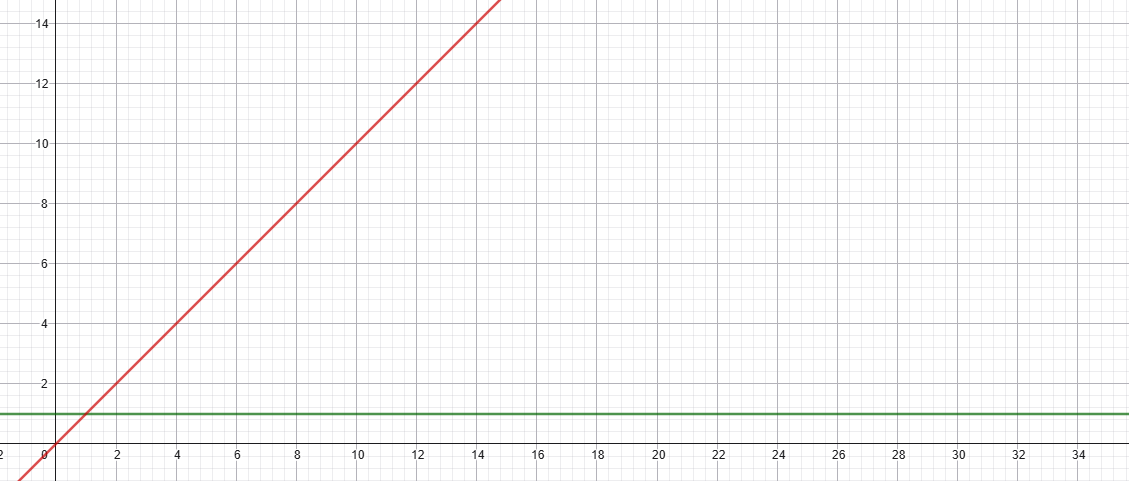


el mejor caso es el verde y el peor el rojo






## 6) Código funcional **[15 pts]**
Incluye tu implementación completa.

No pegues código incompleto; debe ser ejecutable.


In [22]:
def revisar(mes):
    if type(mes) != int:
        print("entrada invalida: el mes debe ser un numero entero")
        return False
    if mes < 0:
        print("entrada invalida: el mes no puede ser negativo")
        return False
    return True

def brotes(mes, tabla, cont):
    if tabla[mes] != -1:
        cont[1] = cont[1] + 1
        return tabla[mes]
    cont[0] = cont[0] + 1
    if mes < 2:
        tabla[mes] = mes
    else:
        tabla[mes] = brotes(mes - 1, tabla, cont) + brotes(mes - 2, tabla, cont)
    return tabla[mes]

def reporte(mes):
    if not revisar(mes):
        return None
    tabla = [-1] * (mes + 1)
    cont = [0, 0]
    nuevas = brotes(mes, tabla, cont)
    print("plantas nuevas en el mes", mes, ":", nuevas)
    print()
    print("mes , plantas , acumulado")
    print("----------------------------")
    total = 0
    for i in range(mes + 1):
        total = total + tabla[i]
        print(i, "|", tabla[i], "|", total)
    print()
    print("acumulado hasta el mes", mes, ":", total)
    print("valores calculados:", cont[0], "| leidos:", cont[1])
    return nuevas

reporte(6)

plantas nuevas en el mes 6 : 8

mes , plantas , acumulado
----------------------------
0 | 0 | 0
1 | 1 | 1
2 | 1 | 2
3 | 2 | 4
4 | 3 | 7
5 | 5 | 12
6 | 8 | 20

acumulado hasta el mes 6 : 20
valores calculados: 7 | leidos: 4


8

## 7) Tests aplicados **[15 pts]**




In [21]:
print("PRUEBAS")

assert brotes(0, [-1] * 1, [0, 0]) == 0
assert brotes(1, [-1] * 2, [0, 0]) == 1
print("casos base: ok")

assert brotes(10, [-1] * 11, [0, 0]) == 55
assert brotes(20, [-1] * 21, [0, 0]) == 6765
print("casos conocidos: ok")

cont = [0, 0]
brotes(30, [-1] * 31, cont)
assert cont[0] == 31
print("memoizacion: ok, valores calculados =", cont[0], "| leidos =", cont[1])

assert reporte(-3) == None
assert reporte(4.5) == None
assert reporte("diez") == None
print("entradas malas: ok")

assert brotes(500, [-1] * 501, [0, 0]) > 0
print("mes 500: ok")

print("todas las pruebas pasaron")

PRUEBAS
casos base: ok
casos conocidos: ok
memoizacion: ok, valores calculados = 31 | leidos = 28
entrada invalida: el mes no puede ser negativo
entrada invalida: el mes debe ser un numero entero
entrada invalida: el mes debe ser un numero entero
entradas malas: ok
mes 500: ok
todas las pruebas pasaron
